In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  


df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv')


(342, 2) (342, 1)
(342, 3)
[0] loss = 20618.9573


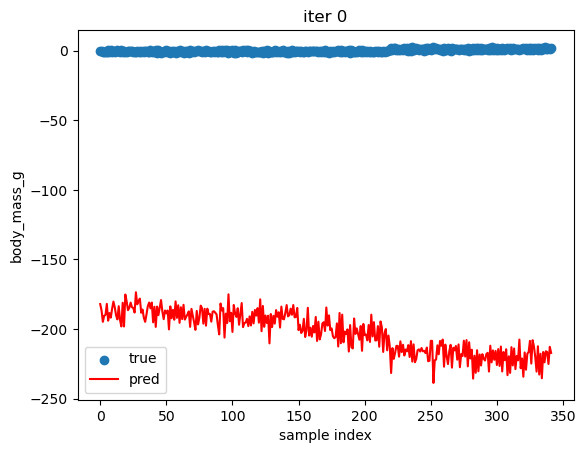

[20] loss = 20271.3176


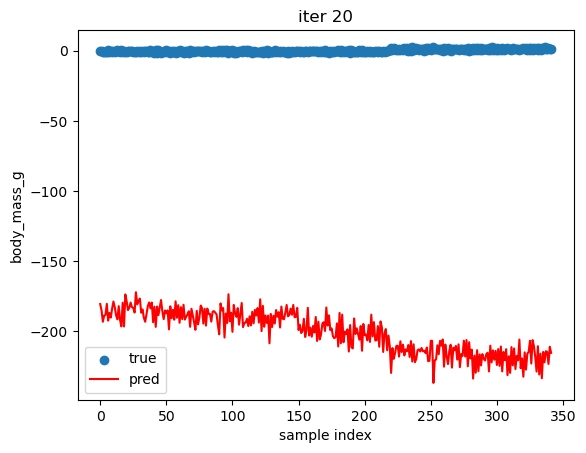

[40] loss = 19929.5402


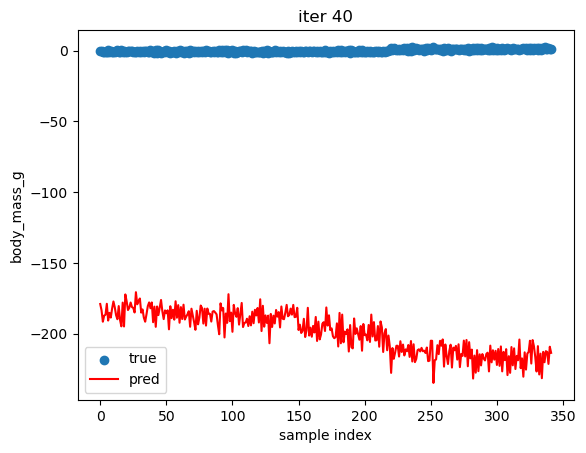

[60] loss = 19593.5260


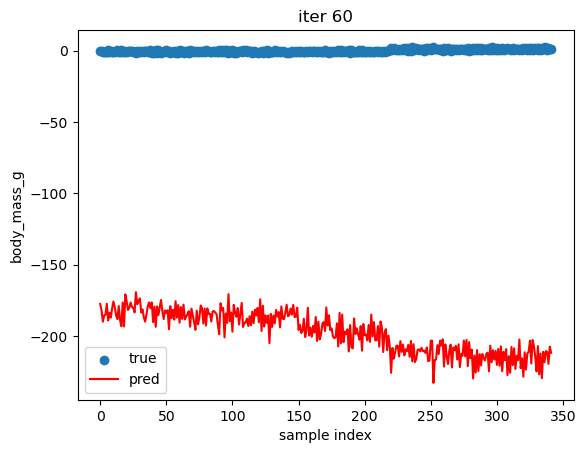

[80] loss = 19263.1781


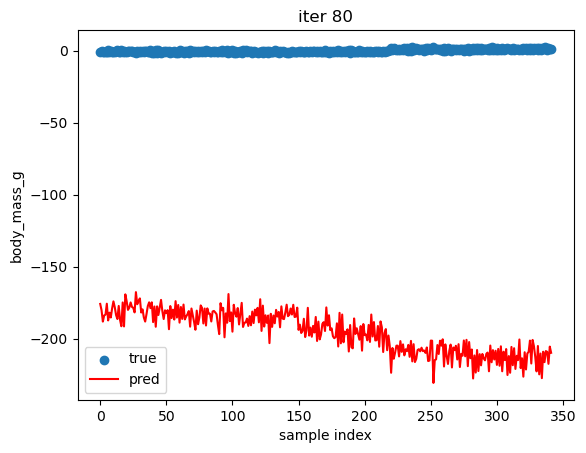

[100] loss = 18938.4007


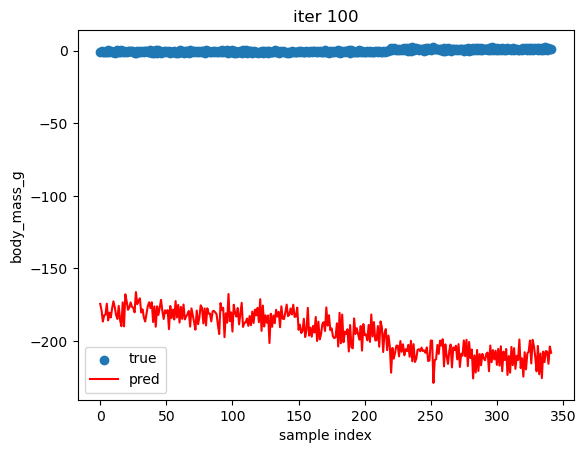

[120] loss = 18619.1000


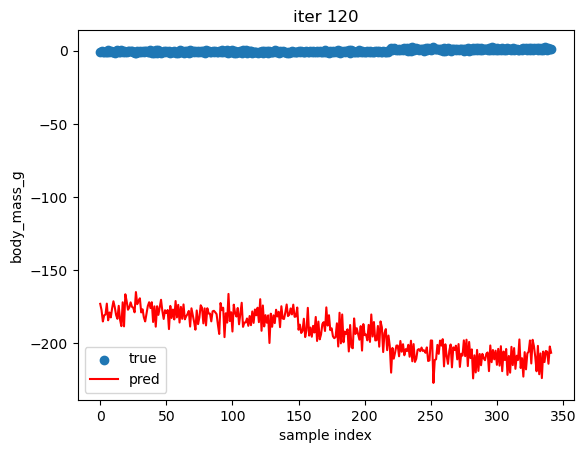

[140] loss = 18305.1836


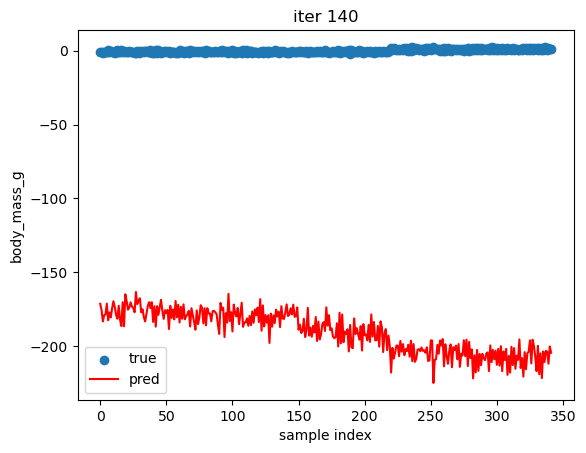

[160] loss = 17996.5607


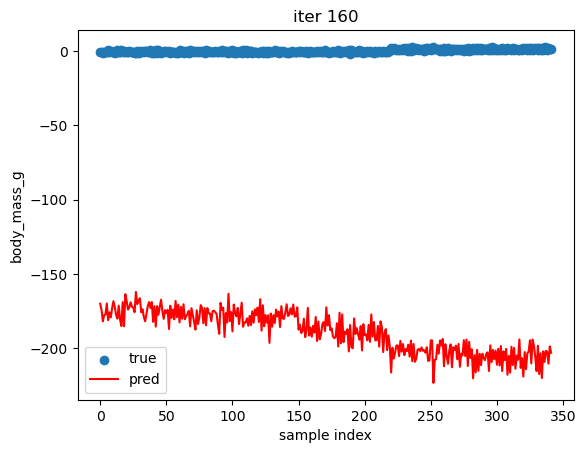

[180] loss = 17693.1421


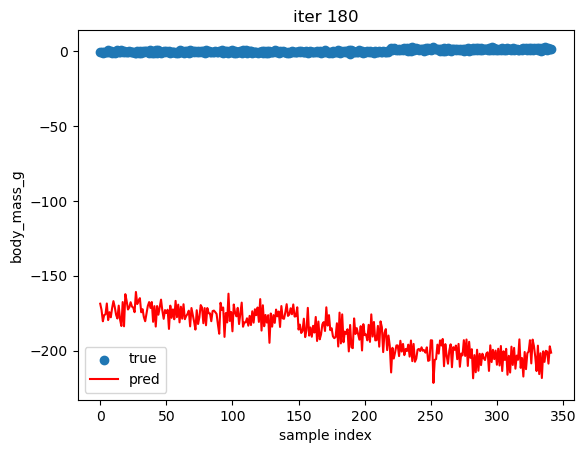

Final W: [-0.72552727 -0.76626166 -0.13135611]


In [4]:
def show_plot(y_pred, Y):
    plt.scatter(np.arange(len(Y)), Y, label="true")
    plt.plot(y_pred, label="pred", color="red")
    plt.legend()
    plt.xlabel("sample index")
    plt.ylabel("body_mass_g")
def predict(W, X):
    y_pred = np.dot(X, W)
    return y_pred

def J(y_pred, Y):
    loss = 1 / 2 * (y_pred - Y)**2
    return loss

def J_gradient(y_pred, Y, X):
    j_gradients = (y_pred - Y)*X # list of all gradients for each training sample
#     return j_gradients
    grad_mean = j_gradients.mean(axis=0)              # mean gradient over samples
    return grad_mean.reshape(-1, 1)

def W_update(W_old, j_grad, alpha=0.00000001):
    W_new = W_old - alpha * j_grad
    return W_new




# اختيار الأعمدة من Penguins
features = ['bill_length_mm', 'flipper_length_mm']
target = 'body_mass_g'

# حذف الصفوف اللي فيها قيم ناقصة
df2 = df[features + [target]].dropna()

# تحويل لـ numpy
X = df2[features].to_numpy()
Y = df2[target].to_numpy().reshape(-1, 1)


#الخط يقرب من النقاط
Y_mean = Y.mean()
Y_std = Y.std()
Y_scaled = (Y - Y_mean) / Y_std
Y = Y_scaled

print(X.shape, Y.shape)


use_bias = True

if use_bias:
    X = np.hstack((X, np.ones((X.shape[0], 1))))
print(X.shape)

W = 2 * np.random.uniform(size=(X.shape[1], 1)) - 1

alpha = 1e-8
epochs = 200

for i in range(epochs):
    y_pred = predict(W, X)  
    loss = J(y_pred, Y).mean()   
    j_grad = J_gradient(y_pred, Y, X)      
    W = W_update(W, j_grad, alpha)    

    if i % 20 == 0:
        print(f"[{i}] loss = {loss:.4f}")
        show_plot(y_pred, Y)
        plt.title(f"iter {i}")
        plt.show()
        plt.close()

print("Final W:", W.reshape(-1))